# Customer Acquisition Response Predictor

Predicting which customers respond to a bank's direct-marketing campaign, and grouping
customers into segments to guide targeting. This mirrors the kind of prospect-marketing
analytics used to make acquisition spending more efficient.

**What this notebook does**
1. Load and explore the data
2. Clean and prepare it for modelling
3. Build a Logistic Regression baseline (simple, explainable)
4. Build an XGBoost model (stronger, handles complex patterns)
5. Compare the two fairly
6. Read which factors drive response
7. Segment customers with K-Means
8. Draw practical conclusions

Dataset: UCI Bank Marketing (`bank-additional-full.csv`, 41,188 rows). A copy is included
in `data/` so the notebook runs offline.

## 1. Setup and load the data

We load the standard libraries and read the CSV. The file is semicolon-separated (a UCI
quirk), so we set `sep=';'`. We fix a random seed everywhere so every run gives the same
numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/bank-additional-full.csv", sep=";")
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Explore the data (EDA)

Before modelling, we look at what we have: the target balance and a few key features.

The target is `y` — did the customer subscribe to the product (yes/no). We turn it into a
1/0 column called `target` so models can use it.

In [2]:
df["target"] = (df["y"] == "yes").astype(int)
base_rate = df["target"].mean()
print(f"Overall subscribe rate: {base_rate:.3f}  ({base_rate*100:.1f}%)")
print("This is imbalanced — most customers say no. That matters for how we score models.")
df["y"].value_counts()

Overall subscribe rate: 0.113  (11.3%)
This is imbalanced — most customers say no. That matters for how we score models.


y
no     36548
yes     4640
Name: count, dtype: int64

A few quick charts: the class balance, age distribution, and subscribe rate by a couple
of categorical features. These tell us who tends to say yes.

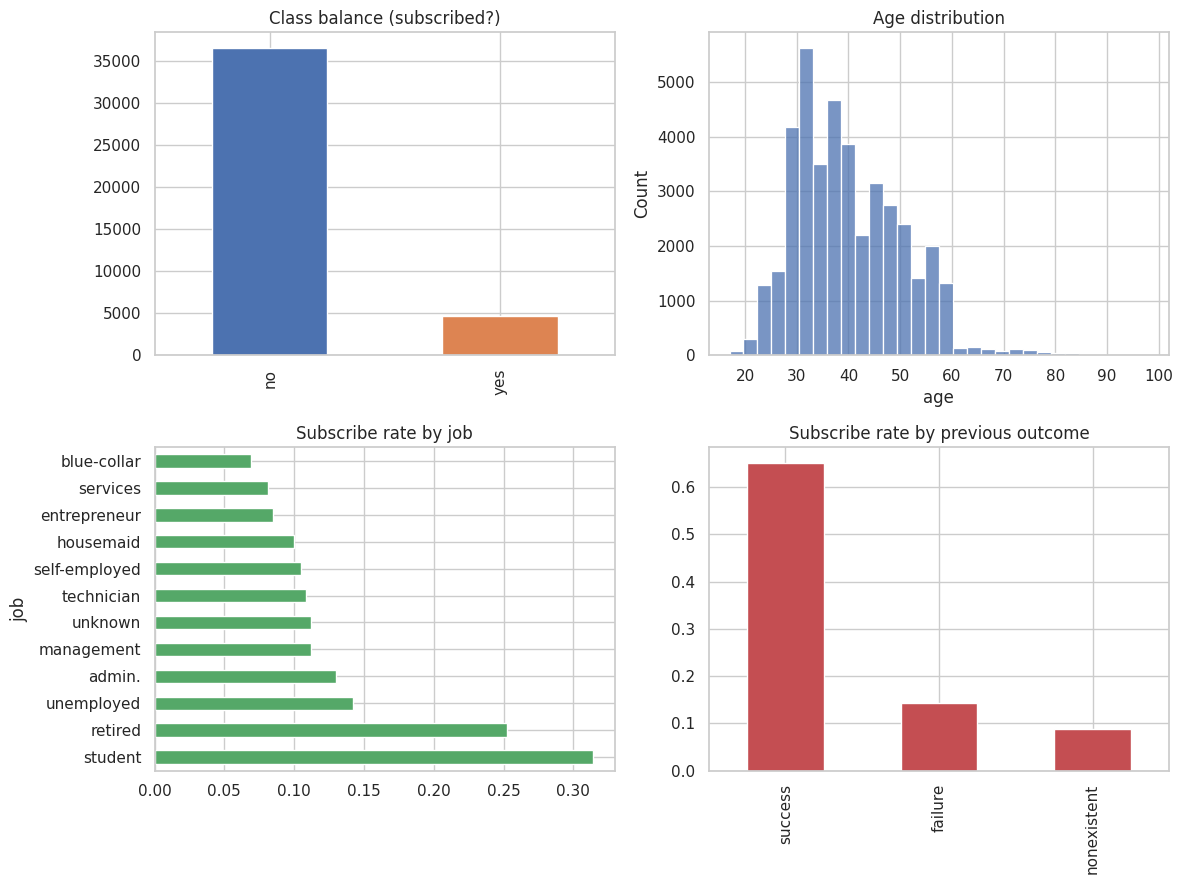

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# class balance
df["y"].value_counts().plot(kind="bar", ax=axes[0,0], color=["#4C72B0","#DD8452"])
axes[0,0].set_title("Class balance (subscribed?)"); axes[0,0].set_xlabel("")

# age
sns.histplot(df["age"], bins=30, ax=axes[0,1], color="#4C72B0")
axes[0,1].set_title("Age distribution")

# subscribe rate by job (top categories)
job_rate = df.groupby("job")["target"].mean().sort_values(ascending=False)
job_rate.plot(kind="barh", ax=axes[1,0], color="#55A868")
axes[1,0].set_title("Subscribe rate by job")

# subscribe rate by prior campaign outcome
po = df.groupby("poutcome")["target"].mean().sort_values(ascending=False)
po.plot(kind="bar", ax=axes[1,1], color="#C44E52")
axes[1,1].set_title("Subscribe rate by previous outcome"); axes[1,1].set_xlabel("")

plt.tight_layout(); plt.show()

**Read:** customers whose previous campaign was a success subscribe far more often, and
subscribe rate varies a lot by job (students and retired are high). This is a strong hint
that past-contact history will matter in the models.

## 3. Prepare the data

Two important cleaning steps, both about not cheating:

- **Drop `duration`** (how long the call lasted). You only know it *after* the call ends,
  so using it to predict who to call would be cheating (data leakage). The UCI docs say to
  drop it for a realistic model. This is why our accuracy is lower than tutorials that keep it.
- **`pdays` = 999** means "never contacted before". That's not really a number of days, so
  we replace it with a clean 0/1 flag `previously_contacted`.

Then we one-hot encode the text columns and scale the numeric ones.

In [4]:
df = df.drop(columns=["duration"])
df["previously_contacted"] = (df["pdays"] != 999).astype(int)
df = df.drop(columns=["pdays"])

y = df["target"]
X = df.drop(columns=["y", "target"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train / test:", X_train.shape[0], "/", X_test.shape[0])

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']
Train / test: 32950 / 8238


/tmp/ipykernel_497/136984487.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


## 4. Model 1 — Logistic Regression (the baseline)

Logistic regression is the simple, explainable model: it draws a boundary and outputs a
probability of "yes". We set `class_weight='balanced'` so the model pays attention to the
rare yes-cases instead of just predicting no for everyone.

Because the classes are imbalanced, **ROC-AUC** is the metric to watch — it measures how well
the model ranks likely subscribers, regardless of the cutoff. Accuracy alone is misleading here.

In [5]:
logit = Pipeline([("pre", pre),
                  ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                             random_state=RANDOM_STATE))])
logit.fit(X_train, y_train)
log_pred = logit.predict(X_test)
log_prob = logit.predict_proba(X_test)[:, 1]

def score(name, ytrue, ypred, yprob):
    return {"model": name,
            "accuracy": accuracy_score(ytrue, ypred),
            "precision": precision_score(ytrue, ypred),
            "recall": recall_score(ytrue, ypred),
            "f1": f1_score(ytrue, ypred),
            "roc_auc": roc_auc_score(ytrue, yprob)}

m_log = score("Logistic Regression", y_test, log_pred, log_prob)
m_log

{'model': 'Logistic Regression',
 'accuracy': 0.8350327749453751,
 'precision': 0.36771025168815225,
 'recall': 0.6454741379310345,
 'f1': 0.4685177942901838,
 'roc_auc': 0.8009878119250908}

## 5. Model 2 — XGBoost (the stronger model)

XGBoost builds many small decision trees in sequence, each fixing the last one's mistakes.
It captures non-linear patterns a single linear model can't. We handle the imbalance with
`scale_pos_weight` (the ratio of no's to yes's), so the comparison against the baseline is fair.

This is a sensible untuned configuration (one train/test split, no cross-validation) — enough
to compare honestly, not a squeezed-for-Kaggle score.

In [6]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb = Pipeline([("pre", pre),
                ("clf", XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                                      subsample=0.9, colsample_bytree=0.9,
                                      scale_pos_weight=spw, eval_metric="auc",
                                      random_state=RANDOM_STATE, n_jobs=4))])
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
m_xgb = score("XGBoost", y_test, xgb_pred, xgb_prob)
m_xgb

{'model': 'XGBoost',
 'accuracy': 0.8475358096625395,
 'precision': 0.39238845144356954,
 'recall': 0.6443965517241379,
 'f1': 0.48776508972267535,
 'roc_auc': 0.8091627995424312}

## 6. Compare the two models

Side by side, plus an ROC curve overlaying both. The closer a curve hugs the top-left, the
better the model ranks subscribers.

                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.8350     0.3677  0.6455  0.4685   0.8010
XGBoost                0.8475     0.3924  0.6444  0.4878   0.8092


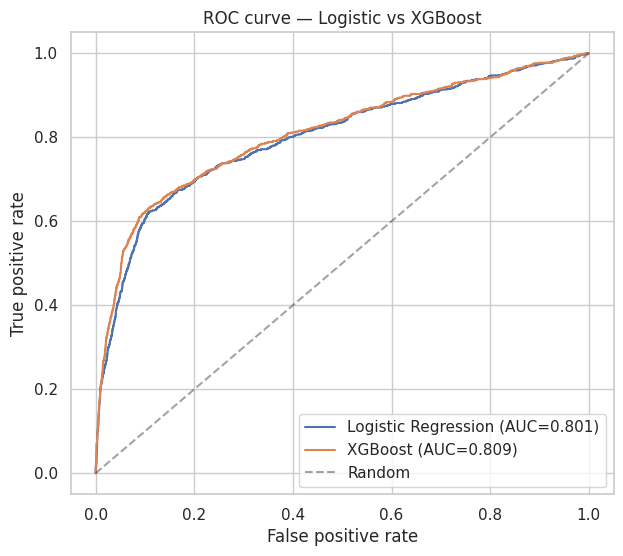

In [7]:
comparison = pd.DataFrame([m_log, m_xgb]).set_index("model").round(4)
print(comparison.to_string())

plt.figure(figsize=(7,6))
for name, prob in [("Logistic Regression", log_prob), ("XGBoost", xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], "k--", alpha=0.4, label="Random")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curve — Logistic vs XGBoost"); plt.legend(); plt.show()

**Business translation — top-decile lift.** AUC is abstract, so here is the practical
version: if we rank everyone by predicted probability and call only the top 10%, how many
more subscribers do we get per call than calling at random?

In [8]:
order = np.argsort(-xgb_prob)
n10 = int(len(xgb_prob) * 0.10)
top10_rate = y_test.values[order][:n10].mean()
lift = top10_rate / y_test.mean()
print(f"Top 10% by model score subscribe at {top10_rate*100:.1f}% "
      f"vs {y_test.mean()*100:.1f}% base -> {lift:.2f}x lift")

Top 10% by model score subscribe at 54.7% vs 11.3% base -> 4.85x lift


Confusion matrices — where each model is right and wrong on the test set.

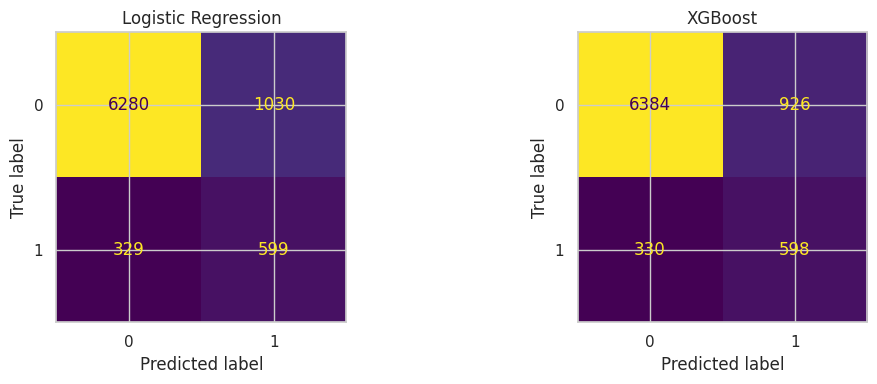

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
ConfusionMatrixDisplay(confusion_matrix(y_test, log_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay(confusion_matrix(y_test, xgb_pred)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("XGBoost")
plt.tight_layout(); plt.show()

## 7. What drives response (feature importance)

XGBoost can tell us which inputs it leaned on most. This is what you'd take to a marketing
team as "here's what predicts a yes".

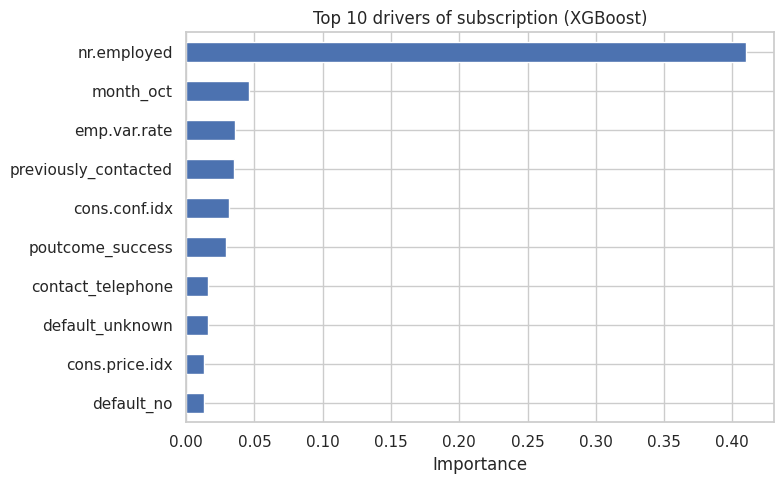

nr.employed             0.4100
month_oct               0.0463
emp.var.rate            0.0360
previously_contacted    0.0350
cons.conf.idx           0.0310
poutcome_success        0.0292
contact_telephone       0.0161
default_unknown         0.0159
cons.price.idx          0.0128
default_no              0.0128
dtype: float32

In [10]:
ohe = xgb.named_steps["pre"].named_transformers_["cat"]
feat_names = num_cols + list(ohe.get_feature_names_out(cat_cols))
importances = pd.Series(xgb.named_steps["clf"].feature_importances_, index=feat_names)
top = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
top[::-1].plot(kind="barh", color="#4C72B0")
plt.title("Top 10 drivers of subscription (XGBoost)"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()
top.round(4)

**Read:** the biggest driver is `nr.employed` — a macro-economic indicator (national
employment level), which tracks the wider climate people decide in. After that, a **prior
successful contact** (`poutcome_success`, `previously_contacted`) and the **month** matter.
The practical takeaway: past-contact history and timing are the levers marketing can actually pull.

## 8. Customer segmentation (K-Means)

Separate from prediction, we group customers into segments on their own characteristics, so
each group can be targeted differently. We use age, contact intensity, and prior-contact
history. We pick the number of groups with the elbow method rather than by eye.

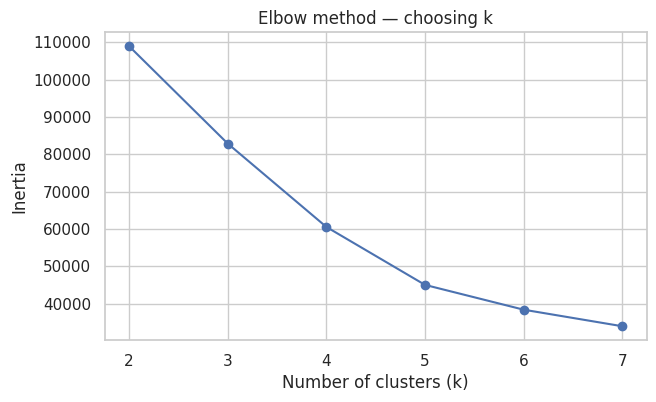

In [11]:
seg_feats = ["age", "campaign", "previous", "previously_contacted"]
X_seg = StandardScaler().fit_transform(df[seg_feats])

inertias = []
Ks = range(2, 8)
for k in Ks:
    inertias.append(KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_seg).inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(Ks), inertias, "o-")
plt.xlabel("Number of clusters (k)"); plt.ylabel("Inertia")
plt.title("Elbow method — choosing k"); plt.show()

In [12]:
k_final = 4
km = KMeans(n_clusters=k_final, n_init=10, random_state=RANDOM_STATE).fit(X_seg)
df["segment"] = km.labels_

seg_summary = df.groupby("segment").agg(
    size=("target", "size"),
    subscribe_rate=("target", "mean"),
    avg_age=("age", "mean"),
    avg_campaign_calls=("campaign", "mean"),
    prev_contacted_share=("previously_contacted", "mean")).round(3)
seg_summary

,size,subscribe_rate,avg_age,avg_campaign_calls,prev_contacted_share
segment,,,,,
0,1723,0.039,39.669,12.554,0.00
1,13762,0.094,51.191,2.168,0.00
2,1530,0.634,41.878,1.826,0.99
3,24173,0.095,33.574,2.130,0.00


**Read:** one segment stands out — customers who were **previously contacted with a prior
success** subscribe at a far higher rate than everyone else, while a group hit with many calls
in this campaign barely converts. Targeting warm, previously-successful customers and easing off
the over-contacted group is the obvious efficiency move.

## 9. Summary of results

Everything the README reports, in one place.

In [13]:
print("Base subscribe rate: {:.1f}%".format(base_rate*100))
print()
print(comparison.to_string())
print()
print(f"XGBoost top-10% lift: {lift:.2f}x")
print()
print("Segments:")
print(seg_summary.to_string())

Base subscribe rate: 11.3%

                     accuracy  precision  recall      f1  roc_auc
model                                                            
Logistic Regression    0.8350     0.3677  0.6455  0.4685   0.8010
XGBoost                0.8475     0.3924  0.6444  0.4878   0.8092

XGBoost top-10% lift: 4.85x

Segments:
          size  subscribe_rate  avg_age  avg_campaign_calls  prev_contacted_share
segment                                                                          
0         1723           0.039   39.669              12.554                  0.00
1        13762           0.094   51.191               2.168                  0.00
2         1530           0.634   41.878               1.826                  0.99
3        24173           0.095   33.574               2.130                  0.00


## 10. So what — conclusions and limits

**Use:** XGBoost is the model to deploy for scoring, but only marginally ahead of logistic
regression once the leaky `duration` feature is removed — so logistic regression is a perfectly
defensible, more explainable fallback. The real value is in *ranking*: calling the top-scored
tenth of customers finds subscribers at several times the base rate.

**Target:** focus on customers with a prior successful contact; stop over-calling the segment
that shows call-fatigue and low conversion.

**Limits (honest):** single train/test split, no hyper-parameter tuning or cross-validation;
macro-economic features dominate importance, so the model partly reflects the wider climate rather
than individual behaviour; results are on historical Portuguese bank data and would need
re-validation on current, local data before real use.